In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


In [3]:
df = pd.read_csv("C:/Users/caiov/OneDrive/Desktop/glass+identification/glass.data",header=None)

df.columns = ["Id","RI", "Na", "Mg", "Al", "Si","K", "Ca", "Ba", "Fe", "Class"]

df = df.drop(columns=["Id"])

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Class
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
print("Shape:", df.shape)

#214 amostras, 10 features e 1 coluna target(classe)

Shape: (214, 10)


In [5]:
print(df.isnull().sum())
#sem valores faltante menos mal

RI       0
Na       0
Mg       0
Al       0
Si       0
K        0
Ca       0
Ba       0
Fe       0
Class    0
dtype: int64


Distribuição percentual das classes:
Class
2    35.514019
1    32.710280
7    13.551402
3     7.943925
5     6.074766
6     4.205607
Name: proportion, dtype: float64


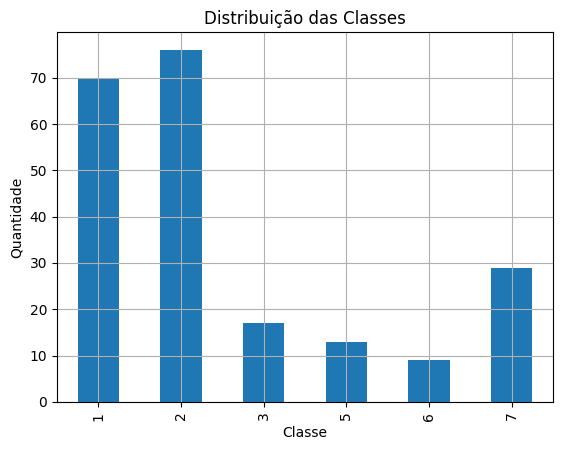

In [6]:
df["Class"].value_counts().sort_index().plot(kind="bar")
print("Distribuição percentual das classes:")
print(df["Class"].value_counts(normalize=True) * 100)
plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.grid()
plt.show()

#Observa-se desbalanceamento entre as classes

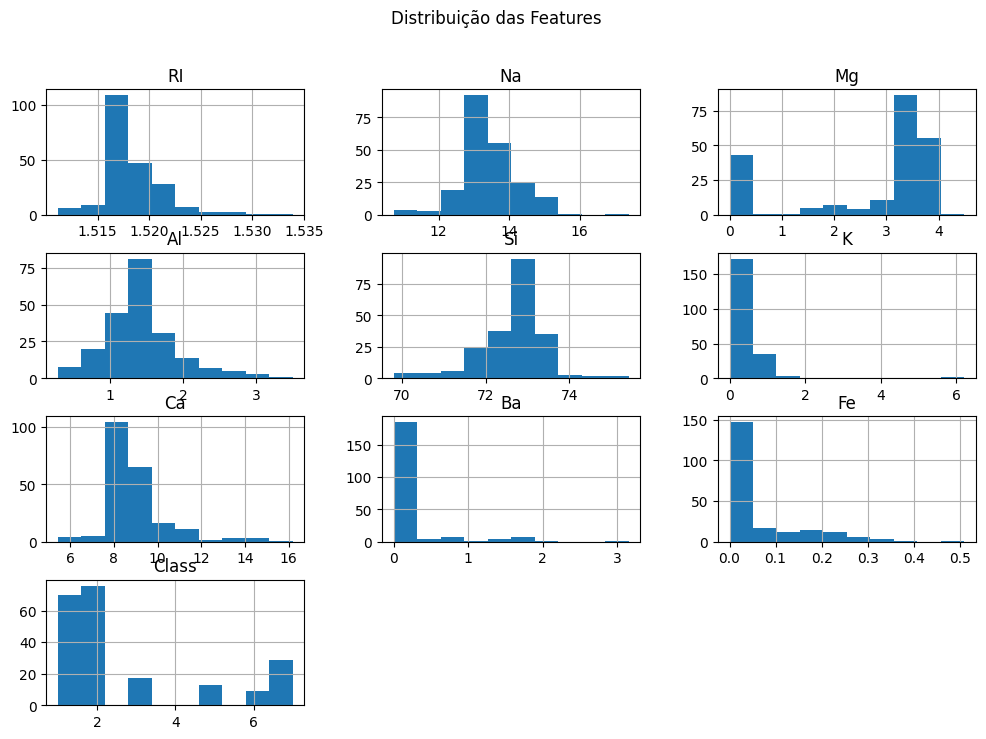

In [7]:
df.hist(figsize=(12,8))
plt.suptitle("Distribuição das Features")
plt.show()


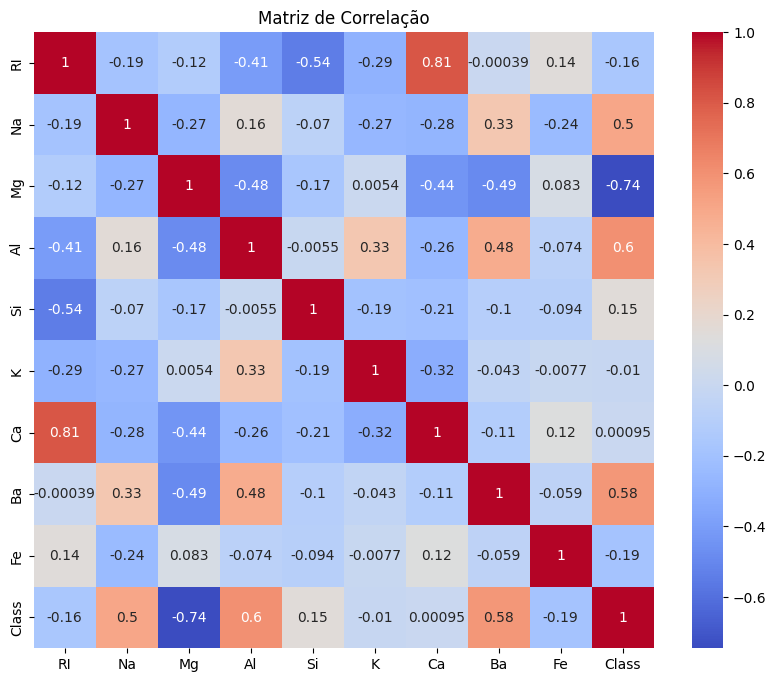

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()


In [9]:
X = df.drop(columns=["Class"]).values
y = df["Class"].values


In [10]:
def rodar_experimento(test_size, normalizar):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )
    
    if normalizar:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    model = LogisticRegression(max_iter=10000)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")
    
    return acc, f1


In [11]:
divisoes = [0.3, 0.2, 0.1]  #70/30, 80/20, 90/10

resultados_divisoes = []

for t in divisoes:
    acc, f1 = rodar_experimento(test_size=t, normalizar=True)
    resultados_divisoes.append(
        (f"{int((1-t)*100)}/{int(t*100)}", acc, f1)
    )

df_resultados_div = pd.DataFrame(
    resultados_divisoes,
    columns=["Divisão", "Acurácia", "F1_macro"]
)

df_resultados_div


,Divisão,Acurácia,F1_macro
0,70/30,0.707692,0.670662
1,80/20,0.720930,0.684005
2,90/10,0.681818,0.657330


In [12]:
melhor_div = df_resultados_div.loc[df_resultados_div["F1_macro"].idxmax()]

print("Melhor divisão encontrada:")
print(melhor_div)

divisao_str = melhor_div["Divisão"]

parte_teste = int(divisao_str.split("/")[1])

melhor_test_size = parte_teste / 100

print("Test size numérico:", melhor_test_size)



Melhor divisão encontrada:
Divisão        80/20
Acurácia     0.72093
F1_macro    0.684005
Name: 1, dtype: object
Test size numérico: 0.2


In [13]:
configs = [True, False]

resultados_norm = []

for norm in configs:
    acc, f1 = rodar_experimento(test_size=0.2, normalizar=norm)
    resultados_norm.append(
        ("Com Normalização" if norm else "Sem Normalização", acc, f1)
    )

df_resultados_norm = pd.DataFrame(
    resultados_norm,
    columns=["Configuração", "Acurácia", "F1_macro"]
)

df_resultados_norm


,Configuração,Acurácia,F1_macro
0,Com Normalização,0.720930,0.684005
1,Sem Normalização,0.674419,0.611495


In [14]:
melhor_norm = df_resultados_norm.loc[df_resultados_norm["F1_macro"].idxmax()]

print("Melhor configuração de normalização:")
print(melhor_norm)

usar_normalizacao = True if melhor_norm["Configuração"] == "Com Normalização" else False
print("Usar normalização?", usar_normalizacao)


Melhor configuração de normalização:
Configuração    Com Normalização
Acurácia                 0.72093
F1_macro                0.684005
Name: 0, dtype: object
Usar normalização? True


In [15]:
test_size = melhor_test_size
normalizar = usar_normalizacao

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=42,
    stratify=y
)

if normalizar:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Acurácia final:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


Acurácia final: 0.7209302325581395

Classification Report:

              precision    recall  f1-score   support

           1       0.71      0.71      0.71        14
           2       0.67      0.67      0.67        15
           3       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       0.86      1.00      0.92         6

    accuracy                           0.72        43
   macro avg       0.65      0.73      0.68        43
weighted avg       0.69      0.72      0.70        43



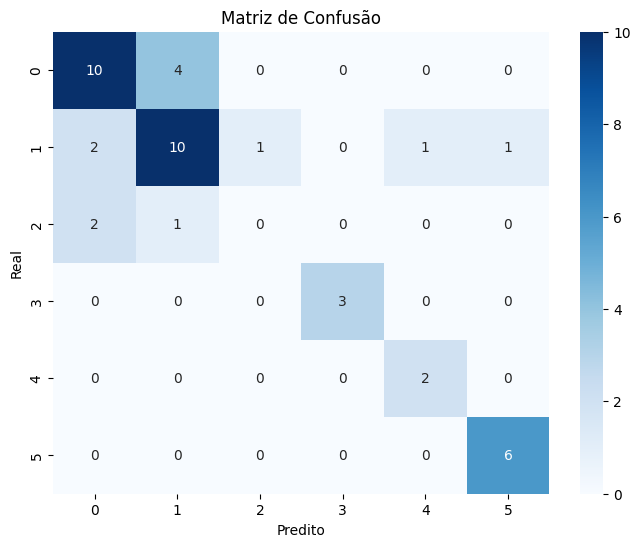

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()
